# Exp0.1.3 — Doc-faithful SAE-Dense Regularization
Analysis-only notebook for the 30 binary direct-SNN regularized runs paired against frozen Exp0.1 controls.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('artifacts/experiment_0_1_3_doc_faithful_regularization/doc_faithful_sae_dense_binary_v1')
manifest = json.loads((ROOT / 'manifest.json').read_text())
runs = pd.read_csv(ROOT / 'runs.csv')
summary = pd.read_csv(ROOT / 'summary.csv')
comparison = pd.read_csv(ROOT / 'comparison_summary.csv')
paired = pd.read_csv(ROOT / 'paired_regularization_effects.csv')
objective_interactions = pd.read_csv(ROOT / 'regularization_objective_interactions.csv')
architecture_interactions = pd.read_csv(ROOT / 'regularization_architecture_interactions.csv')
manifest


{'base_experiment': {'experiment_id': 'experiment_0_1_general_comparison',
  'protocol_version': 'general_comparison_v1',
  'reuse': '30 frozen binary direct reg-off runs + frozen binary probe/raw context'},
 'direct_architectures': {'mid_long': [[2, 3, 4, 5], [2, 3, 4, 5, 6, 7]],
  'short_mid': [[2, 3], [2, 3, 4, 5]],
  'short_mid_long': [[2, 3], [2, 3, 4, 5], [2, 3, 4, 5, 6, 7]]},
 'experiment_id': 'experiment_0_1_3_doc_faithful_regularization',
 'files': {'baselines': 'baseline_results.csv',
  'binary_probe_context': 'binary_probe_context.csv',
  'comparison_summary': 'comparison_summary.csv',
  'paired_regularization_effects': 'paired_regularization_effects.csv',
  'regularization_architecture_interactions': 'regularization_architecture_interactions.csv',
  'regularization_objective_interactions': 'regularization_objective_interactions.csv',
  'runs': 'runs.csv',
  'summary': 'summary.csv'},
 'new_training_run_count': 30,
 'preserved_training_parameters': {'batch_size': 128,
  'che

## Five-seed performance summary


In [2]:
display(summary.sort_values(['architecture', 'objective', 'regularization']))
display(comparison.sort_values('mean_test_ba', ascending=False))


,family,architecture,objective,variant,regularization,primary_readout,test_ba_mean,test_ba_std,test_ba_count,test_accuracy_mean,...,test_accuracy_count,test_macro_f1_mean,test_macro_f1_std,test_macro_f1_count,native_test_ba_mean,native_test_ba_std,native_test_ba_count,test_last_hidden_events_per_neuron_second_mean,test_last_hidden_events_per_neuron_second_std,test_last_hidden_events_per_neuron_second_count
0,direct_snn,mid_long,timestep_ce,binary,doc_sae_dense_on,output_whole_count,0.067541,0.015364,5,0.063014,...,5,0.027964,0.020617,5,0.067541,0.015364,5,1.759385,1.203636,5
1,direct_snn,mid_long,timestep_ce,binary,off,output_whole_count,0.304034,0.044997,5,0.319178,...,5,0.240477,0.045242,5,0.304034,0.044997,5,8.332745,1.777456,5
2,direct_snn,mid_long,whole_count_ce,binary,doc_sae_dense_on,output_whole_count,0.067541,0.015364,5,0.063014,...,5,0.027980,0.020602,5,0.067541,0.015364,5,1.759452,1.203528,5
3,direct_snn,mid_long,whole_count_ce,binary,off,output_whole_count,0.400790,0.030637,5,0.413699,...,5,0.381113,0.030675,5,0.400790,0.030637,5,11.645353,0.866013,5
4,direct_snn,short_mid,timestep_ce,binary,doc_sae_dense_on,output_whole_count,0.083333,0.000000,5,0.075342,...,5,0.011784,0.000168,5,0.083333,0.000000,5,0.042586,0.018587,5
5,direct_snn,short_mid,timestep_ce,binary,off,output_whole_count,0.281464,0.025165,5,0.300000,...,5,0.221717,0.031170,5,0.281464,0.025165,5,3.639480,0.918831,5
6,direct_snn,short_mid,whole_count_ce,binary,doc_sae_dense_on,output_whole_count,0.083333,0.000000,5,0.075342,...,5,0.011784,0.000168,5,0.083333,0.000000,5,0.042586,0.018587,5
7,direct_snn,short_mid,whole_count_ce,binary,off,output_whole_count,0.457210,0.026985,5,0.472603,...,5,0.435882,0.040386,5,0.457210,0.026985,5,9.917578,0.874293,5
8,direct_snn,short_mid_long,timestep_ce,binary,doc_sae_dense_on,output_whole_count,0.085390,0.007714,5,0.078082,...,5,0.021314,0.009753,5,0.085390,0.007714,5,0.329589,0.309241,5
9,direct_snn,short_mid_long,timestep_ce,binary,off,output_whole_count,0.132105,0.015682,5,0.136986,...,5,0.092941,0.016807,5,0.132105,0.015682,5,2.007074,0.480077,5


,system,family,architecture,objective,variant,regularization,mean_test_ba,sd_test_ba,n
14,Raw Relative10 + Linear,raw_linear_baseline,relative10,posthoc_linear,deterministic,not_applicable,0.739481,NaN,1
12,snn_fixed250_linear:local_234x2:timestep_ce:bi...,snn_fixed250_linear,local_234x2,timestep_ce,binary,not_applicable,0.595437,0.032058,5
13,Raw Fixed250 + Linear,raw_linear_baseline,fixed250,posthoc_linear,deterministic,not_applicable,0.548475,NaN,1
7,direct_snn:short_mid:whole_count_ce:binary:reg...,direct_snn,short_mid,whole_count_ce,binary,off,0.457210,0.026985,5
3,direct_snn:mid_long:whole_count_ce:binary:reg=off,direct_snn,mid_long,whole_count_ce,binary,off,0.400790,0.030637,5
1,direct_snn:mid_long:timestep_ce:binary:reg=off,direct_snn,mid_long,timestep_ce,binary,off,0.304034,0.044997,5
5,direct_snn:short_mid:timestep_ce:binary:reg=off,direct_snn,short_mid,timestep_ce,binary,off,0.281464,0.025165,5
11,direct_snn:short_mid_long:whole_count_ce:binar...,direct_snn,short_mid_long,whole_count_ce,binary,off,0.218723,0.015720,5
9,direct_snn:short_mid_long:timestep_ce:binary:r...,direct_snn,short_mid_long,timestep_ce,binary,off,0.132105,0.015682,5
10,direct_snn:short_mid_long:whole_count_ce:binar...,direct_snn,short_mid_long,whole_count_ce,binary,doc_sae_dense_on,0.085390,0.007714,5


## Paired regularization effect


,architecture,objective,mean_delta_ba,sd_delta_ba,mean_delta_event_rate,mean_dead_fraction
0,mid_long,timestep_ce,-0.236493,0.032503,-6.573360,0.250000
1,mid_long,whole_count_ce,-0.333248,0.018674,-9.885901,0.250000
2,short_mid,timestep_ce,-0.198130,0.025165,-3.596894,0.623437
3,short_mid,whole_count_ce,-0.373877,0.026985,-9.874992,0.623437
4,short_mid_long,timestep_ce,-0.046715,0.019862,-1.677485,0.468750
5,short_mid_long,whole_count_ce,-0.133333,0.016191,-4.439339,0.468750


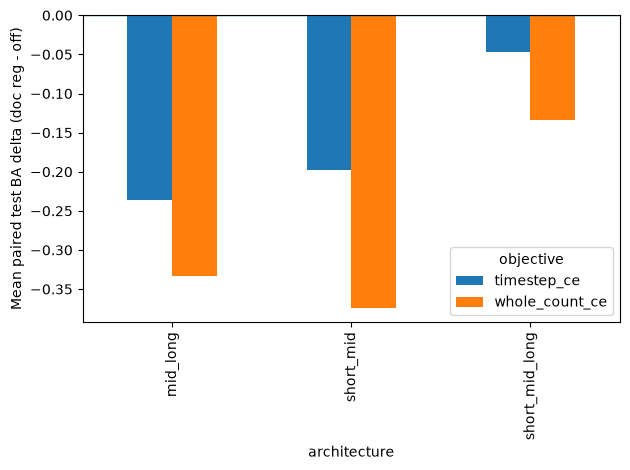

In [3]:
effect = (paired.groupby(['architecture', 'objective'])
          .agg(mean_delta_ba=('delta_test_ba_doc_reg_minus_off', 'mean'),
               sd_delta_ba=('delta_test_ba_doc_reg_minus_off', 'std'),
               mean_delta_event_rate=('delta_last_hidden_events_per_neuron_second', 'mean'),
               mean_dead_fraction=('on_test_mean_dead_neuron_fraction', 'mean'))
          .reset_index())
display(effect)
ax = effect.pivot(index='architecture', columns='objective', values='mean_delta_ba').plot(kind='bar')
ax.axhline(0, linewidth=1)
ax.set_ylabel('Mean paired test BA delta (doc reg - off)')
plt.tight_layout()


## Objective and architecture interactions


In [4]:
display(objective_interactions.groupby('architecture').mean(numeric_only=True))
display(architecture_interactions.groupby(['comparison', 'objective']).mean(numeric_only=True))


,seed,interaction_doc_reg_delta_timestep_minus_whole_count
architecture,,
mid_long,39.0,0.096756
short_mid,39.0,0.175747
short_mid_long,39.0,0.086619


seed  \
comparison            objective              
add_long_layer        timestep_ce     39.0   
                      whole_count_ce  39.0   
shift_coverage_longer timestep_ce     39.0   
                      whole_count_ce  39.0   

                                      interaction_doc_reg_delta_candidate_minus_baseline  
comparison            objective                                                           
add_long_layer        timestep_ce                                              0.151415   
                      whole_count_ce                                           0.240543   
shift_coverage_longer timestep_ce                                             -0.038363   
                      whole_count_ce                                           0.040629

## Training-scale diagnostics
Read existing history CSVs only. Check whether weighted P2/A1 dominate the task objective and which P2 layer contributes most.


In [5]:
history_files = sorted((ROOT / 'histories').glob('*.csv'))
history_rows = []
for path in history_files:
    h = pd.read_csv(path)
    for which, row in [('first', h.iloc[0]), ('last', h.iloc[-1])]:
        item = {'run': path.stem, 'point': which}
        for col in h.columns:
            if col in {'train_task_loss', 'train_p2', 'train_a1', 'train_weighted_p2', 'train_weighted_a1', 'train_reg_to_task_ratio', 'train_p2_output'} or col.startswith('train_p2_hidden_'):
                item[col] = row[col]
        history_rows.append(item)
history_scale = pd.DataFrame(history_rows)
display(history_scale)
display(history_scale.groupby('point').mean(numeric_only=True))


,run,point,train_task_loss,train_p2,train_a1,train_weighted_p2,train_weighted_a1,train_reg_to_task_ratio,train_p2_hidden_1,train_p2_hidden_2,train_p2_output,train_p2_hidden_3
0,direct_snn__mid_long__timestep_ce__binary__hca...,first,2.885988,8.666228e+07,1586.222693,8.666228e+05,158.622275,300341.282239,1.460182e+06,8.504718e+07,154911.944531,NaN
1,direct_snn__mid_long__timestep_ce__binary__hca...,last,2.485335,1.538132e+05,14.659080,1.538132e+03,1.465908,619.473060,1.013931e+05,5.220278e+04,217.401997,NaN
2,direct_snn__mid_long__timestep_ce__binary__hca...,first,3.877845,1.669895e+08,2295.856372,1.669895e+06,229.585638,430683.592654,1.256342e+06,1.649259e+08,807237.393750,NaN
3,direct_snn__mid_long__timestep_ce__binary__hca...,last,2.487223,2.073275e+05,22.737609,2.073275e+03,2.273761,834.484378,1.190325e+05,8.784170e+04,453.305058,NaN
4,direct_snn__mid_long__timestep_ce__binary__hca...,first,3.084939,9.473778e+07,2200.394922,9.473778e+05,220.039496,307169.035821,1.661150e+06,9.253735e+07,539283.371875,NaN
5,direct_snn__mid_long__timestep_ce__binary__hca...,last,2.485447,1.367760e+05,6.810368,1.367760e+03,0.681037,550.581385,9.370481e+04,4.293244e+04,138.745851,NaN
6,direct_snn__mid_long__timestep_ce__binary__hca...,first,3.084906,4.152248e+07,1533.533704,4.152248e+05,153.353374,134648.577393,1.562374e+06,3.981856e+07,141545.185938,NaN
7,direct_snn__mid_long__timestep_ce__binary__hca...,last,2.484874,1.103691e+05,5.546120,1.103691e+03,0.554612,444.386963,8.296996e+04,2.730847e+04,90.671596,NaN
8,direct_snn__mid_long__timestep_ce__binary__hca...,first,2.696697,4.306042e+07,995.514191,4.306042e+05,99.551419,159715.311708,1.552787e+06,4.129302e+07,214612.918750,NaN
9,direct_snn__mid_long__timestep_ce__binary__hca...,last,2.485210,1.173217e+05,7.397342,1.173217e+03,0.739734,472.377202,7.930244e+04,3.788213e+04,137.118075,NaN


,train_task_loss,train_p2,train_a1,train_weighted_p2,train_weighted_a1,train_reg_to_task_ratio,train_p2_hidden_1,train_p2_hidden_2,train_p2_output,train_p2_hidden_3
point,,,,,,,,,,
first,2.645063,3.641676e+07,670.119145,364167.603327,67.011916,126656.223447,713332.735104,2.844266e+07,138001.023399,2.136829e+07
last,2.485055,5.789036e+04,4.285984,578.903634,0.428598,233.097322,38861.988195,1.794171e+04,82.285713,3.013136e+03
